# Ex2-局部线性加权回归

The Mean Square Loss: 0.3365507639747307


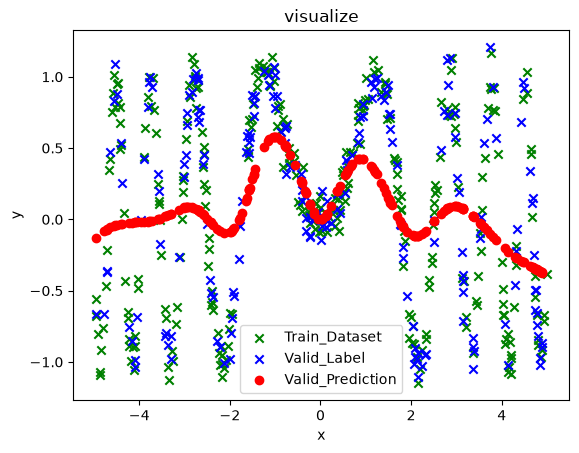

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#载入数据
def read_data(path):
    with open(path,'r') as file:
        header=file.readline().strip().split(',')

    x_cols=[i for i in range(len(header)) if header[i].startswith('x')]
    y_cols=[i for i in range(len(header)) if header[i].startswith('y')]

    inputs=np.loadtxt(path,delimiter=',',skiprows=1,usecols=x_cols)
    labels=np.loadtxt(path,delimiter=',',skiprows=1,usecols=y_cols)

    if inputs.ndim==1:
        inputs=inputs.reshape(-1,1)

    return inputs,labels

class LocallyWeightedLinearRegression:
    def __init__(self,x,y,tau):
        self.x=x
        self.y=y
        self.tau=tau
        self.last_theta=None

    def fit(self,val):
        predictions=[]
        for x in val:
            distances=np.linalg.norm(self.x-x,axis=1)
            weights=np.diag(np.exp(-distances**2/(2*self.tau**2)))
            self.last_theta=np.linalg.inv(self.x.T @ weights @ self.x) @ self.x.T @ weights @ self.y 
            predictions.append(self.last_theta.T @ x)
        return predictions

def main(path1,path2,tau):
    train_inputs,train_labels=read_data(path1)
    val_inputs,val_labels=read_data(path2)

    train=LocallyWeightedLinearRegression(train_inputs,train_labels,tau)
    predictions=train.fit(val_inputs)

    means=np.mean((val_labels-predictions)**2)
    print(f"The Mean Square Loss: {means}")

    plt.figure()
    plt.scatter(train_inputs[:,0],train_labels,c='g',marker='x',label='Train_Dataset')
    plt.scatter(val_inputs[:,0],val_labels,c='b',marker='x',label='Valid_Label')
    plt.scatter(val_inputs[:,0],predictions,c='r',marker='o',label='Valid_Prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('visualize')
    plt.savefig('lwr',dpi=300)
    plt.show()


if __name__=='__main__':
    main('train.csv','valid.csv',0.5)

**Conclusion:** 结合图片，我们不难看出采用这种方式进行训练，最终得到的结果是underfit(欠拟合了)